In [11]:
import numpy as np
import scipy.stats as st
import matplotlib.pyplot as plt


In [17]:
def upper_q (k,n,p) :
     return(1-st.binom.cdf(k, n, p))


def fixed_perc_p_retrain (n,v, f) :
    k=np.ceil(f*n)
    return(upper_q(k-1,n-1,v)+st.binom.pmf(k-1,n,v)*v)
    # return(upper_q(k,n,v))  #possibile alternative

def n_retrains_idlesteps(retrain_prob, shift_length, stream_length, idle_steps_number=1, verbose=False) :
    mean_step_length=(1-retrain_prob)*idle_steps_number+shift_length*retrain_prob
    mean_steps_mumber=stream_length/mean_step_length
    mean_retr_number=mean_steps_mumber*retrain_prob
    if verbose :
        print(f'p_retrain = {retrain_prob}')
        print(f's = {shift_length}')
        print(f'mean step length = {mean_step_length}')    
        print(f'mean useful steps mumber = {mean_steps_mumber}')  
        print(f'expected retrains number={mean_retr_number}') 
    return(mean_retr_number)




def n_retrains_Wald(retrain_prob, shift_length, stream_length) :
     mean_step_length=retrain_prob*(shift_length-1)+1
     return({'lower bound' : (stream_length*retrain_prob)/mean_step_length,  #the same as n_retrains_*
             'upper bound' : (stream_length+shift_length)*retrain_prob/mean_step_length})







# Fixed threshold method

In [45]:
v = 0.1   # outlier detector's (one class classifier) characteristic 

M=8000      # stream size
n=250       # window size
f=0.1       # threshold: fraction of outliers sufficient for triggering a retrain

p_retrain=fixed_perc_p_retrain(n,v,f)


keep=0.1 # as Antoine does      # fraction of window kept in case of retraining
perc_no_overlap=1-keep
s=np.floor(n*perc_no_overlap)   # step length in case of retrain

idle_steps_number=n*f           # rough mean 

expected_retrains=n_retrains_idlesteps(retrain_prob=p_retrain, shift_length=s, stream_length=M, 
                     idle_steps_number=idle_steps_number, verbose=True)


p_retrain = 0.5307893558149229
s = 225.0
mean step length = 131.15787116298458
mean useful steps mumber = 60.995195553751586
expected retrains number=32.375600555781055


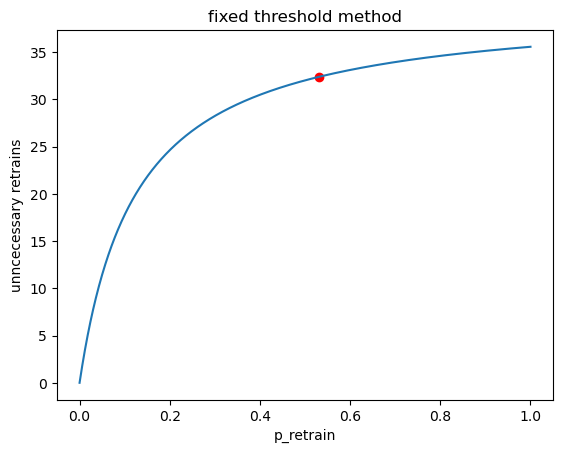

In [46]:
p_values = np.linspace(0, 1, num=1000)

nn_retrains=n_retrains_idlesteps(retrain_prob=p_values, shift_length=s, stream_length=M, 
                     idle_steps_number=idle_steps_number)

plt.plot(p_values, nn_retrains)
plt.scatter(p_retrain, expected_retrains, color='red')
plt.xlabel("p_retrain")
plt.ylabel("unncecessary retrains")
plt.title("fixed threshold method")
#plt.legend()
#plt.grid(True)
plt.show()

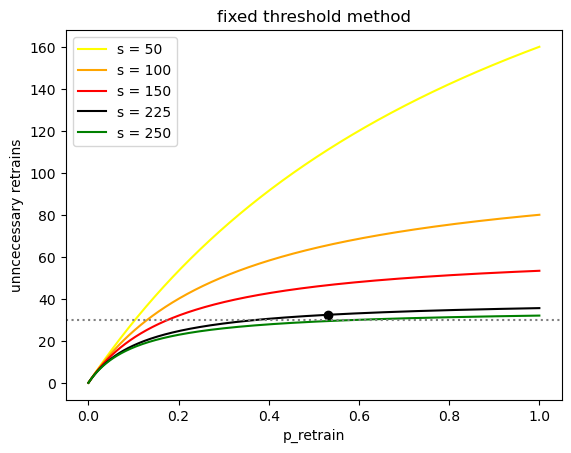

In [48]:
p_values = np.linspace(0, 1, num=1000)
s_values = [50, 100, 150, 225, 250]
colors = ['yellow', 'orange', 'red', 'black', 'green']

for s, color in zip(s_values, colors):
    n_retrains = n_retrains_idlesteps(retrain_prob=p_values, shift_length=s, stream_length=M, 
                     idle_steps_number=idle_steps_number)
    plt.plot(p_values, n_retrains, color=color, label=f"s = {s}")

plt.scatter(p_retrain, expected_retrains, color='black')
plt.xlabel("p_retrain")
plt.ylabel("unncecessary retrains")
plt.title("fixed threshold method")
plt.legend()
#plt.grid(True)
plt.axhline(y=30, color='grey', linestyle='dotted') 
plt.show()

For a window size n=250, and a shft size s=225, in order to keep small the number of unnecessary retrains (below 30), p_retrain should be approximately below 0.4, that is f approximately above 0.1 (see plot below).

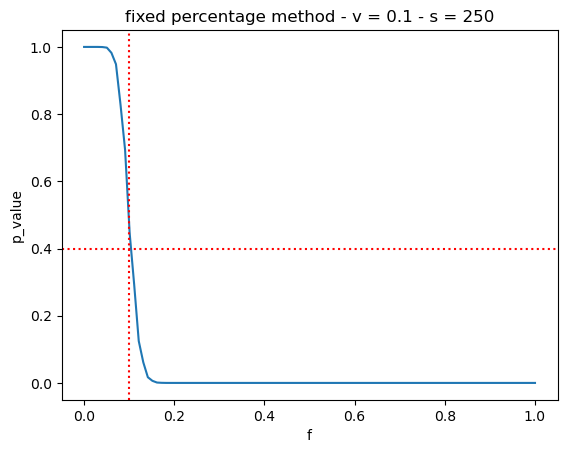

In [49]:
f_values = np.linspace(0,1, num=100)
p_values = fixed_perc_p_retrain(n,v,f_values)  

plt.plot(f_values, p_values)
plt.axhline(y=0.4, color='red', linestyle='dotted') 
plt.axvline(x=0.1, color='red', linestyle='dotted') 
plt.xlabel("f")
plt.ylabel("p_value")
plt.title(f'fixed percentage method - v = {v} - s = {s}')
plt.show()

# z-test method

In [50]:
M=8000
n=250
alfa=0.025

p_retrain=alfa

keep=0.1 # as Antoine does
perc_no_overlap=1-keep
s=np.floor(n*perc_no_overlap)

idle_steps_number=n/2

expected_retrains=n_retrains_idlesteps(retrain_prob=p_retrain, shift_length=s, stream_length=M, 
                     idle_steps_number=idle_steps_number, verbose=True)


p_retrain = 0.025
s = 225.0
mean step length = 127.5
mean useful steps mumber = 62.745098039215684
expected retrains number=1.5686274509803921


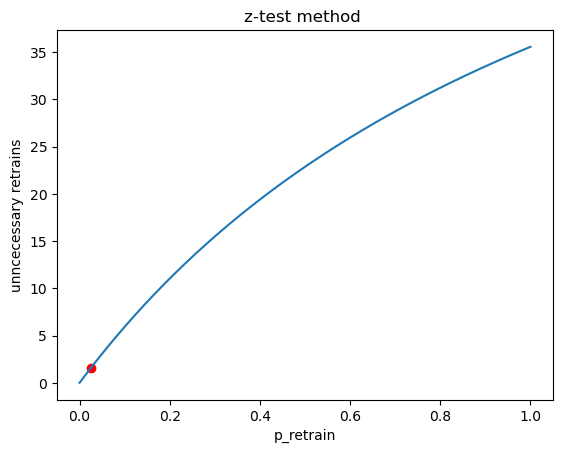

In [51]:
p_values = np.linspace(0, 1, num=1000)

nn_retrains=n_retrains_idlesteps(retrain_prob=p_values, shift_length=s, stream_length=M, 
                     idle_steps_number=idle_steps_number)

plt.plot(p_values, nn_retrains)
plt.scatter(p_retrain, expected_retrains, color='red')
plt.xlabel("p_retrain")
plt.ylabel("unncecessary retrains")
plt.title("z-test method ")
#plt.legend()
#plt.grid(True)
plt.show()

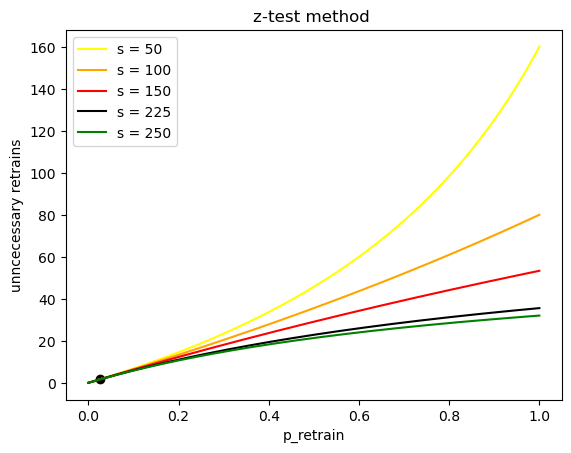

In [53]:
p_values = np.linspace(0, 1, num=1000)
s_values = [50, 100, 150, 225, 250]
colors = ['yellow', 'orange', 'red', 'black', 'green']

for s, color in zip(s_values, colors):
    n_retrains = n_retrains_idlesteps(retrain_prob=p_values, shift_length=s, stream_length=M, 
                     idle_steps_number=idle_steps_number)
    plt.plot(p_values, n_retrains, color=color, label=f"s = {s}")

plt.scatter(p_retrain, expected_retrains, color='black')
plt.xlabel("p_retrain")
plt.ylabel("unncecessary retrains")
plt.title("z-test method ")
plt.legend()
#plt.grid(True)
plt.show()

for $\alpha \leq 0.2$ and shift size $s \leq 50$ the number of unnecessary retrains is small (below 20)